# GX01
# The Double Slit Experiment

In this graded exercise we will investigate how the angular spectrum method models the classical double slit experiment and analyze the field as it propagates to better understand the physics of the simulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from ipywidgets import interact
from ipywidgets import FloatSlider

# Part 1

Let's begin by creating the double slit field that we will propagate. All the required parameters have already been defined for you, so for this section you will just need to manipulate them into the desired field.

Our double slit will be defined by a slit spacing and slit width. The slits should be vertical and should extend from the top to the bottom of the simulation domain (thereby rendering our problem effectively 1D). Note that the provided slit spacing is the distance between the centers of each slit, not the inside edges.

You should define the slit by filling out the generate_double_slit function with the appropriate logic for which regions should permit the passage of intensity and which regions should block it. Use the provided constants alongside the passed slit_width and slit_spacing parameters to return the correct input field for propagation.

After you have defined your slit you can use the provided plotting code to visualize it.

In [2]:
# - No modification necessary -

# Grid parameters
N = 1024                     # number of pixels (square grid)
L = 5e-3                     # total physical size (5 mm)
dx = L / N                   # pixel size

# Spatial grid
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

slit_width = 50e-6          
slit_spacing = 200e-6  

In [3]:
def generate_double_slit(slit_width, slit_spacing):
    raise NotImplementedError

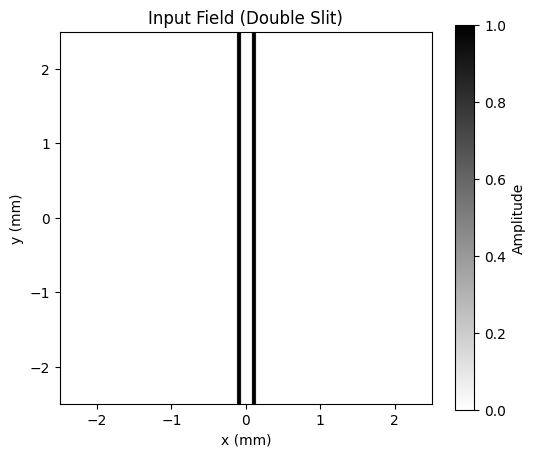

In [4]:
# - No modification necessary -

U0 = generate_double_slit(slit_width, slit_spacing)

plt.figure(figsize=(6,5))
plt.imshow(U0, extent=[x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3], cmap="gray_r")
plt.title("Input Field (Double Slit)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label="Amplitude")
plt.show()

# Part 2
Now that we have defined our input field, let's propagate it and see what the intensity of the field looks like at different propagation distances.

The following code propagates the field by 3 different distances, 1 mm, 10mm, and 100mm, and plots the intensity at each distance. For the two shorter distances the plot is zoomed in to see the details of the features more easily.

For each of the images, please discuss what you observe and why you believe that the field looks the way that it does at that distance. Focus on how the light from the two different slits appears to be interacting at each different distance and the transition from two independent systems to one combined system.

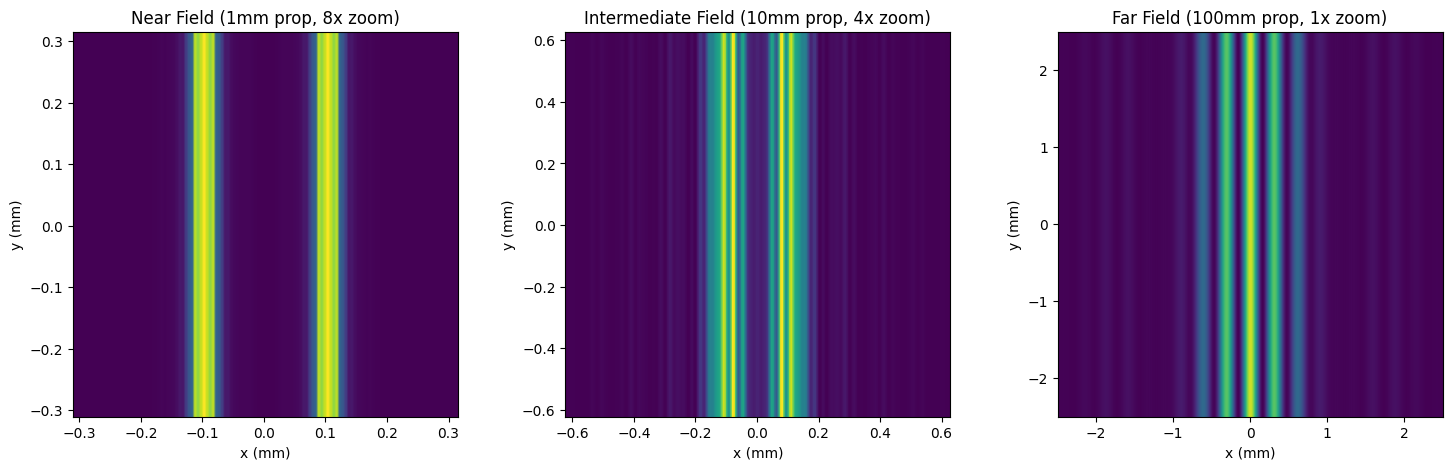

In [5]:
# - No modification necessary -

wavelength = 633e-9
z1 = 1e-3
z2 = 1e-2
z3 = 1e-1

def angular_spectrum_propagation(U0, dx, wavelength, z):
    N = U0.shape[0]
    k = 2 * np.pi / wavelength
    
    fx = np.fft.fftfreq(N, dx)
    fy = np.fft.fftfreq(N, dx)
    FX, FY = np.meshgrid(fx, fy)
    
    kx = 2 * np.pi * FX
    ky = 2 * np.pi * FY
    
    kz = np.sqrt(np.maximum(0, k**2 - kx**2 - ky**2))
    
    H = np.exp(1j * kz * z)
    
    U0_ft = np.fft.fft2(U0)
    Uz_ft = U0_ft * H
    Uz = np.fft.ifft2(Uz_ft)
    
    return Uz

U1 = angular_spectrum_propagation(U0, dx, wavelength, z1)
U2 = angular_spectrum_propagation(U0, dx, wavelength, z2)
U3 = angular_spectrum_propagation(U0, dx, wavelength, z3)

I1 = np.abs(U1)**2
I2 = np.abs(U2)**2
I3 = np.abs(U3)**2

fig, axes = plt.subplots(1,3, figsize=(18,5))

axes[0].imshow(I1[:, 448:576], extent=[x[448]*1e3, x[576]*1e3, y[448]*1e3, y[576]*1e3])
axes[0].set_title("Near Field (1mm prop, 8x zoom)")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")

axes[1].imshow(I2[:, 384:640], extent=[x[384]*1e3, x[640]*1e3, y[384]*1e3, y[640]*1e3])
axes[1].set_title("Intermediate Field (10mm prop, 4x zoom)")
axes[1].set_xlabel("x (mm)")
axes[1].set_ylabel("y (mm)")

axes[2].imshow(I3, extent=[x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3])
axes[2].set_title("Far Field (100mm prop, 1x zoom)")
axes[2].set_xlabel("x (mm)")
axes[2].set_ylabel("y (mm)")

plt.show()

## Discussion
TODO

# Part 3

In this section we will compare the results we have obtained from the angular spectrum method to the analytical solution of the system in the far field.

Recall that the far-field intensity of a plane wave passed through a double slit is given by the equation:
$$
I(\theta) = I_0 
\left( \frac{\sin\left( \frac{\pi a}{\lambda} \sin\theta \right)}
{\frac{\pi a}{\lambda} \sin\theta} \right)^2
\cos^2\left( \frac{\pi d}{\lambda} \sin\theta \right)
$$
for slit width a and slit spacing d.

The code to generate and plot this is already provided and not modification is necessary. After running the code, please answer the following questions:

1) Do the analytical and digitally propagated models appear to match? Try using a variety of slit spacings and widths and comment on how those parameters change the quality and characteristics of the match.
2) Describe the effect of changing the slit width. Does this agree with the analytical model? What about changing the slit spacing. Does this also agree?

In [6]:
# - No modification necessary -

def asm_versus_analytic(slit_width, slit_spacing):
    U0 = generate_double_slit(slit_width, slit_spacing)
    U = angular_spectrum_propagation(U0, dx, wavelength, 1e-1)
    I = np.abs(U)**2

    theta = np.atan(x / 1e-1)
    
    I_analytical = (
        np.cos(np.pi * slit_spacing * np.sin(theta) / wavelength)**2 *
        (np.sinc(slit_width * np.sin(theta) / wavelength))**2
    )
    
    # Normalize both
    I_line = I[N//2, :]
    I_line /= np.max(I_line)
    I_analytical /= np.max(I_analytical)
    
    plt.figure(figsize=(8,5))
    plt.plot(x, I_line, label="Angular Spectrum")
    plt.plot(x, I_analytical, '--', label="Analytical")
    plt.legend()
    plt.xlabel("x (m)")
    plt.ylabel("Normalized Intensity")
    plt.title("Far Field Comparison")
    plt.show()  


interact(
    asm_versus_analytic, 
    slit_width=FloatSlider(min=10e-6, max=100e-6, step=5e-6, readout_format='.6f'), 
    slit_spacing=FloatSlider(min=50e-6, max=500e-6, step=50e-6, readout_format='.6f')
);

interactive(children=(FloatSlider(value=1e-05, description='slit_width', max=0.0001, min=1e-05, readout_format…

## Discussion
TODO

# Bonus
You will have noticed when comparing the angular spectrum method output to the analytical model that there is some error present in our simulation. Below is an x-z cutplane (in log-scale) of our simulation with sliders for the slit width and spacing. Using these levers, can you come up with any conclusions on what might be causing our error and what could be changed to mitigate it?

In [7]:
# - No modifications necessary

def prop_and_plot(slit_width, slit_spacing):
    U0 = generate_double_slit(slit_width, slit_spacing)
    
    z_max = 0.15
    Nz = 50
    z_vals = np.linspace(0, z_max, Nz)
    
    x_index = N // 2  # central y slice
    xz_intensity = np.zeros((Nz, N))
    
    for i, z in enumerate(z_vals):
        Uz = angular_spectrum_propagation(U0, dx, wavelength, z)
        xz_intensity[i,:] = np.abs(Uz[x_index,:])**2
        
    plt.figure(figsize=(7,5))
    plt.imshow(
        xz_intensity,
        extent=[-L/2, L/2, 0, z_max],
        aspect='auto',
        origin='lower',
        norm=LogNorm(vmin=np.min(1e-3),
                     vmax=np.max(xz_intensity))
    )
    
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title("x–z Intensity Cross Section")
    plt.colorbar(label="Intensity")
    plt.show()
    
interact(
    prop_and_plot, 
    slit_width=FloatSlider(min=10e-6, max=100e-6, step=5e-6, readout_format='.6f'), 
    slit_spacing=FloatSlider(min=50e-6, max=500e-6, step=50e-6, readout_format='.6f')
);

interactive(children=(FloatSlider(value=1e-05, description='slit_width', max=0.0001, min=1e-05, readout_format…

## Discussion
TODO